## Desarrollo tarea HW Sesión 2

Felipe López Vergara

Descarga de librerías necesarias

In [ ]:
# Librerías necesarias — no modifique esta celda
from matplotlib import pyplot as plt
from scipy.stats import f_oneway, mannwhitneyu, kruskal, levene, bartlett
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import seaborn as sns
import yfinance as yf
import pandas as pd
import numpy as np

sns.set_style("dark")
np.random.seed(20260607)

### Parte I: Transformación de Datos Financieros (25 puntos)

Trabajará con el siguiente portafolio de activos del sector tecnológico y financiero para el período 2021-01-01 al 2024-12-31:

Ticker	Empresa
AAPL	Apple Inc.
AMZN	Amazon.com Inc.
JPM	    JPMorgan Chase & Co.
GS	    Goldman Sachs Group Inc.
TSLA	Tesla Inc.

Pregunta 1.1 — Retornos Simples y Logarítmicos (8 puntos)

a) Descargue los precios de cierre del portafolio definido anteriormente.

In [13]:
# Extracción de datos utilizando yfinance
def descargar_datos_yf(tickers, start, end):
    data = yf.download(tickers, start=periodo[0], end=periodo[1], progress=False)
    return data

tickers = ['AAPL', 'AMZN','JPM', 'GS', 'TSLA']
periodo = ('2021-01-01', '2024-12-31')

df = descargar_datos_yf(tickers, periodo[0], periodo[1])['Close']
df.head()

Ticker,AAPL,AMZN,GS,JPM,TSLA
2021-01-04,125.740845,159.331497,233.060959,109.491570,243.256668
2021-01-05,127.295494,160.925507,238.276199,110.087349,245.036667
2021-01-06,123.010536,156.919006,251.134125,115.256569,251.993332
2021-01-07,127.208061,158.108002,256.498871,119.041519,272.013336
2021-01-08,128.305969,159.134995,255.118164,119.172958,293.339996


b) Calcule los retornos diarios simples y logarítmicos para cada activo.

In [14]:
# Cálculos de retornos del DataFrame
retornos_simple = df.pct_change().dropna()
retornos_log = np.log(df / df.shift(1))

retornos_log.head()


Ticker,AAPL,AMZN,GS,JPM,TSLA
2021-01-04,NaN,NaN,NaN,NaN,NaN
2021-01-05,0.012288,0.009955,0.022130,0.005427,0.007291
2021-01-06,-0.034241,-0.025212,0.052557,0.045887,0.027995
2021-01-07,0.033554,0.007549,0.021137,0.032312,0.076448
2021-01-08,0.008594,0.006475,-0.005397,0.001104,0.075481


c) Para el activo TSLA, grafique en un mismo panel de dos subplots: la serie de precios y la serie de retornos logarítmicos.

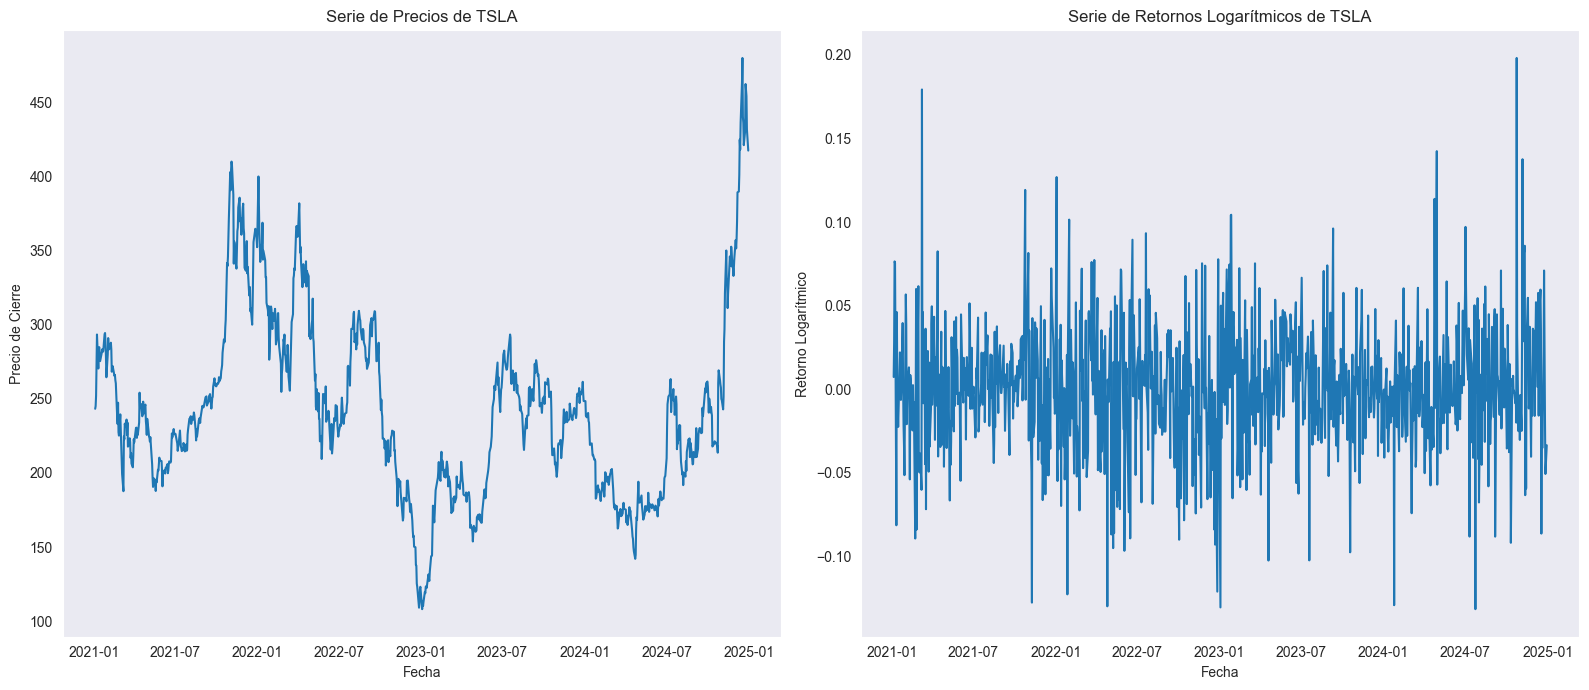

In [15]:
# Serie de Precios y Retornos logarítmicos de Tesla

fig, axes = plt.subplots(1, 2, figsize = (16, 7))

sns.lineplot(data = df['TSLA'], ax = axes[0])
axes[0].set_title('Serie de Precios de TSLA')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Precio de Cierre')  

sns.lineplot(data = retornos_log['TSLA'], ax = axes[1])
axes[1].set_title('Serie de Retornos Logarítmicos de TSLA')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Retorno Logarítmico')

plt.tight_layout() 
plt.show()


d) ¿Qué diferencias observa entre los retornos simples y logarítmicos? ¿En qué escenarios es más conveniente usar retornos logarítmicos? Justifique su respuesta.

El retorno logarítmico refleja de mejor medida el retorno debido a su propiedad aditiva, es decir, muestra más fielmente porque va sumando los rendimientos en el tiempo, en cambio el retorno simple sólo mide la variación del valor respecto del día anterior.
Es mejor utiliazr el retorno logarítmico cuando se trabaja con horzontes más largos ya que permite sumar directamente los rendimientos, simplificando los cálculos y análisis cuantitaiivo